# Make graph of m values for the three methods then print a table of m_t

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [2]:
N = 20000
alpha = 0.8
t = 100

## Get data

In [3]:
## actual table data
cherry_m_values = []

## cop data
cop_m_values = []

## approx data
approx_m_values = []

# read in from each directory the m_values and append to cherry_m_values
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f'trial_{i}/m_values.npy')
    cherry_m_values.append(m_values)

    m_values_cop = np.load(f'other-methods/cop_table_{i}.npy')
    cop_m_values.append(m_values_cop)

    m_values_approx = np.load(f'other-methods/approx_table_{i}.npy')
    approx_m_values.append(m_values_approx)



## Plot m_i for each column

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


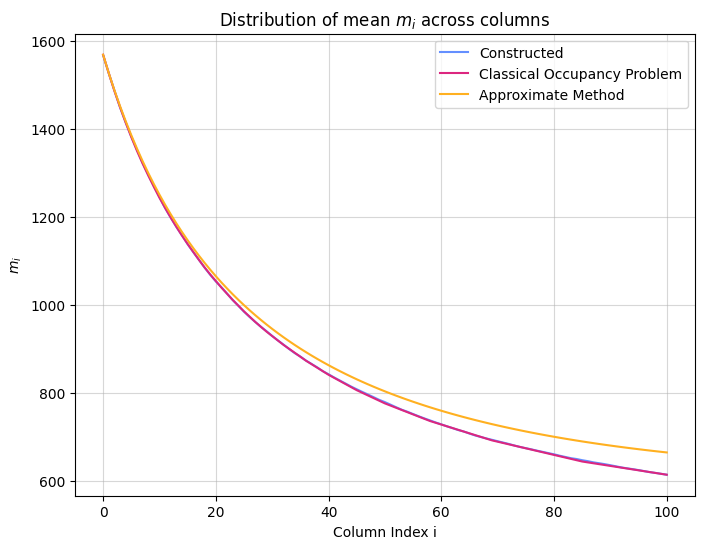

In [4]:
plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Constructed")

## cop data
cop_m_values_array = np.array(np.mean(cop_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cop_m_values_array, color='#dc267f', label="Classical Occupancy Problem")

## approx data
approx_m_values_array = np.array(np.mean(approx_m_values, axis=0))
plt.plot(x_indicies, approx_m_values_array, color='#ffb020', label="Approximate Method")

# set x ticks
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns")
plt.legend()
# plt.grid()
# save as svg
plt.savefig("m_values_distribution.eps", format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


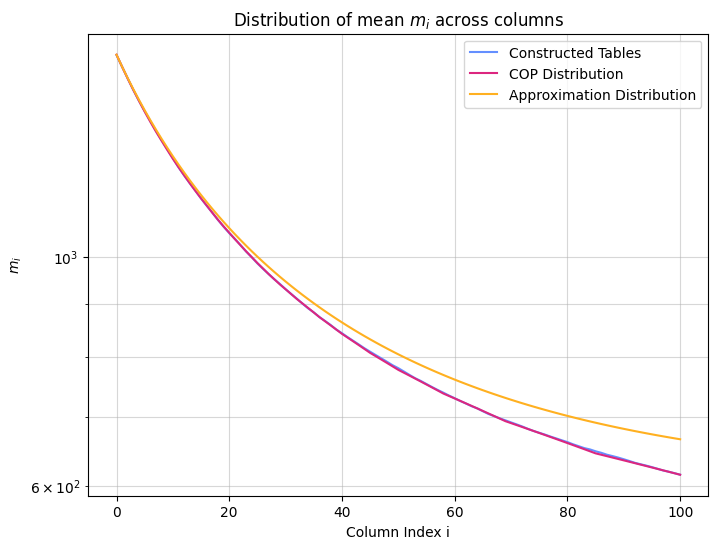

In [19]:
## Do same but use log scale for y?
plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Constructed Tables")

cherry_avg_mt = cherry_m_values_array[-1]
# annotate the end of the line with the average m_t value
y = cherry_m_values_array[-1]
# plt.annotate(round(cherry_avg_mt),
#              xy = (t+5, y),   # place text outside box in line with end of curve
#              xytext = (6, 0),
#              color = '#648fff',
#              textcoords = 'offset points',
#              size=8,
#              va='center')

## cop data
cop_m_values_array = np.array(np.mean(cop_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cop_m_values_array, color='#dc267f', label="COP Distribution")
cop_avg_mt = cop_m_values_array[-1]
# annotate the end of the line with the average m_t value
y = cop_m_values_array[-1]
# plt.annotate(round(cop_avg_mt),
#                 xy = (t+5, y),   # place text outside box in line with end of curve
#                 xytext = (6, 0),
#                 color = '#dc267f',
#                 textcoords = 'offset points',
#                 size=8,
#                 va='center')

## approx data
approx_m_values_array = np.array(np.mean(approx_m_values, axis=0))
plt.plot(x_indicies, approx_m_values_array, color='#ffb020', label="Approximation Distribution")
approx_avg_mt = approx_m_values_array[-1]
# annotate the end of the line with the average m_t value
y = approx_m_values_array[-1]
# plt.annotate(round(approx_avg_mt),
#                 xy = (t+5, y),   # place text outside box in line with end of curve
#                 xytext = (6, 0),
#                 color = '#ffb020',
#                 textcoords = 'offset points',
#                 size=8,
#                 va='center')

# set x ticks
ax = plt.gca()
ax.set_yscale('log')
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns")
plt.legend()
# plt.grid()
# save as svg
plt.savefig("different_methods_m_values_distribution.eps", format='eps', bbox_inches='tight')
plt.show()

In [17]:
# table of avg m_t values for each method
print(f"Average m_t for Constructed Tables: {cherry_avg_mt:.2f}")
print(f"Average m_t for COP Distribution: {cop_avg_mt:.2f}")
print(f"Average m_t for Approximation Distribution: {approx_avg_mt:.2f}")

Average m_t for Constructed Tables: 615.00
Average m_t for COP Distribution: 615.00
Average m_t for Approximation Distribution: 665.60
